In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sys.path.append('../bin')
from bin.functions import *
from bin.permutation import *
from bin.markov_permutation import *
from bin.entropy import *
np.seterr(all = 'ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [14]:
def create_dataset_df(num_series=100000, series_length=1000):
    """
    Создание датасета, содержащего временные ряды разных типов в виде DataFrame.
    
    Параметры:
    - num_series: int, количество временных рядов каждого типа
    - series_length: int, длина каждого временного ряда
    
    Возвращает:
    - dataset: dict, содержащий временные ряды разных типов в виде DataFrame
    """
    dataset = {}
    
    # Создание авторегрессионных временных рядов с малой памятью
    ar2_series = []
    for _ in range(num_series):
        time_series = generate_arma(p=2, q=0, n=series_length)
        ar2_series.append(time_series)
    dataset['ar2'] = pd.DataFrame(ar2_series)
    
    # Создание авторегрессионных временных рядов с большой памятью
    arma_series = []
    for _ in range(num_series):
        time_series = generate_arma(p=10, q=5, n=series_length)
        arma_series.append(time_series)
    dataset['arma'] = pd.DataFrame(arma_series)
    
    # Создание мультифрактальных временных рядов
    multifractal_series = []
    for _ in range(num_series):
        time_series = generate_multifractal(series_length, H=np.random.rand())
        multifractal_series.append(time_series)
    dataset['multifractal'] = pd.DataFrame(multifractal_series)
    
    # Создание трендовых временных рядов
    cos_series = []
    ts_n_series = []
    for _ in range(num_series):
        ts_n, time_series = generate_trend_series(length=series_length, trend_koef=np.random.uniform(low=0, high=0.6), ampl=np.random.uniform(low=0, high=1.5), seasonality_period=12, seasonality_aplitude=np.random.uniform(low=0, high=0.5), sigma=np.random.uniform(low=0.3,high=1.5))
        ts_n_series.append(ts_n)
        cos_series.append(time_series)
    dataset['trend_cos'] = pd.DataFrame(cos_series)
    
    # Создание случайных блужданий
    rand_wolk_series = []

    for _ in range(num_series):
        time_series = np.random.uniform(low=-50, high=50) + generate_rw(series_length)
        rand_wolk_series.append(time_series)
    dataset['random_walk'] = pd.DataFrame(multifractal_series)
    
    return dataset, pd.DataFrame(ts_n_series)

# Создание датасета
dataset_df, trend_series_wo_noise = create_dataset_df(num_series=50, series_length=500)


In [15]:
def calculate_characteristics(dataset_df):
    """
    Вычисление характеристик для каждого временного ряда в датасете и сохранение их в датафрейме.
    
    Параметры:
    - dataset_df: dict, содержащий временные ряды разных типов в виде DataFrame
    
    Возвращает:
    - characteristics_df: DataFrame, содержащий характеристики для каждого временного ряда
    """
    characteristics = {}
    
    # Вычисление характеристик для каждого типа временного ряда
    for key, df in dataset_df.items():
        print(key)
        characteristics[key + '_ent_rate4'] = df.apply(permutation_entropy_rate, args=(4,1,), axis=1)
        characteristics[key + '_ent_rate4_5_jump'] = df.apply(permutation_entropy_rate, args=(4,5,), axis=1)
        characteristics[key + '_perm_ent4'] = df.apply(permutation_entropy, args=(4,), axis=1)
        
        
    # Создание датафрейма с характеристиками
    characteristics_df = pd.DataFrame(characteristics)
    
    return characteristics_df

# Вычисление характеристик для датасета
characteristics_df = calculate_characteristics(dataset_df)

ar2
arma
multifractal
trend_cos
random_walk


In [ ]:
characteristics_df.head()

In [ ]:
characteristics_df.to_csv("../src/feature/artifical_entropy.csv")

In [104]:
characteristics_df = pd.read_csv("../src/feature/artifical_entropy.csv", index_col=0)

In [16]:
characteristics_df["ar2_stationary4"].hist()

KeyError: 'ar2_stationary4'

In [17]:
characteristics_df["arma_stationary4"].hist()

KeyError: 'arma_stationary4'

In [18]:
characteristics_df["multifractal_stationary4"].hist()

KeyError: 'multifractal_stationary4'

In [19]:
characteristics_df["random_walk_stationary4"].hist()

KeyError: 'random_walk_stationary4'

In [20]:
characteristics_df["trend_cos_stationary4"].hist()

KeyError: 'trend_cos_stationary4'

<Axes: >

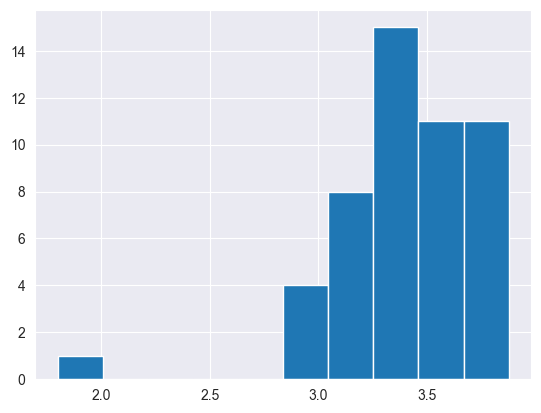

In [21]:
characteristics_df["ar2_ent_rate4"].hist()

<Axes: >

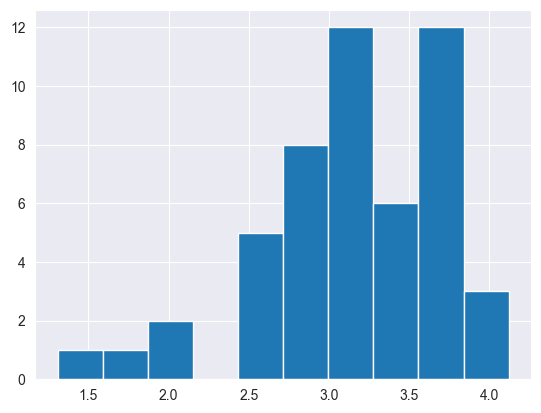

In [22]:
characteristics_df["arma_ent_rate4"].hist()

<Axes: >

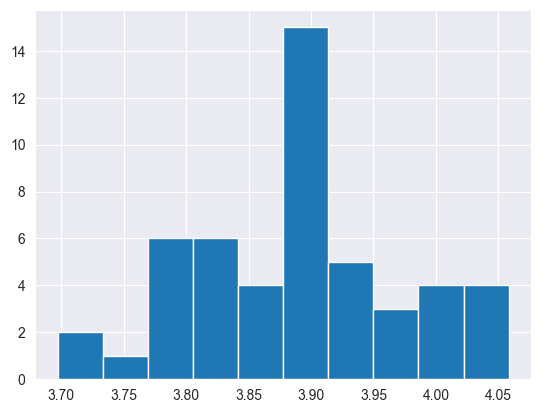

In [23]:
characteristics_df["random_walk_ent_rate4"].hist()

<Axes: >

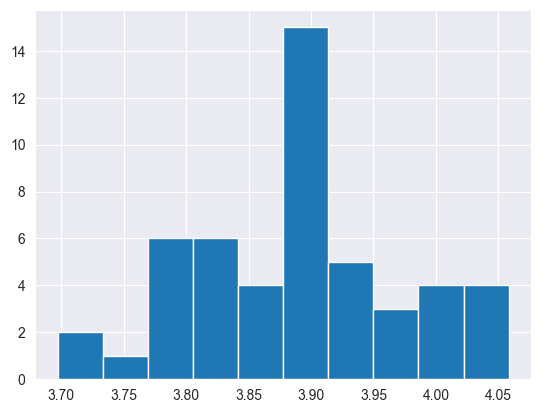

In [24]:
characteristics_df["multifractal_ent_rate4"].hist()

<Axes: >

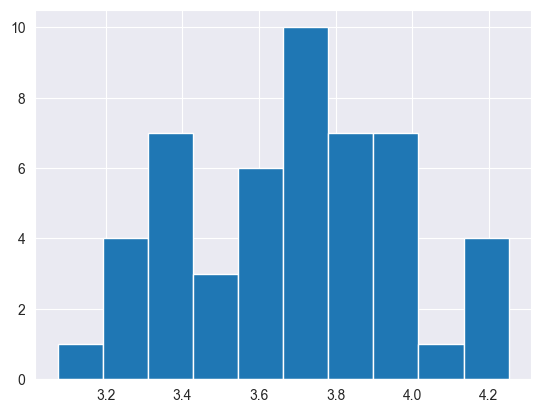

In [25]:
characteristics_df["trend_cos_ent_rate4"].hist()

<Axes: xlabel='value', ylabel='Count'>

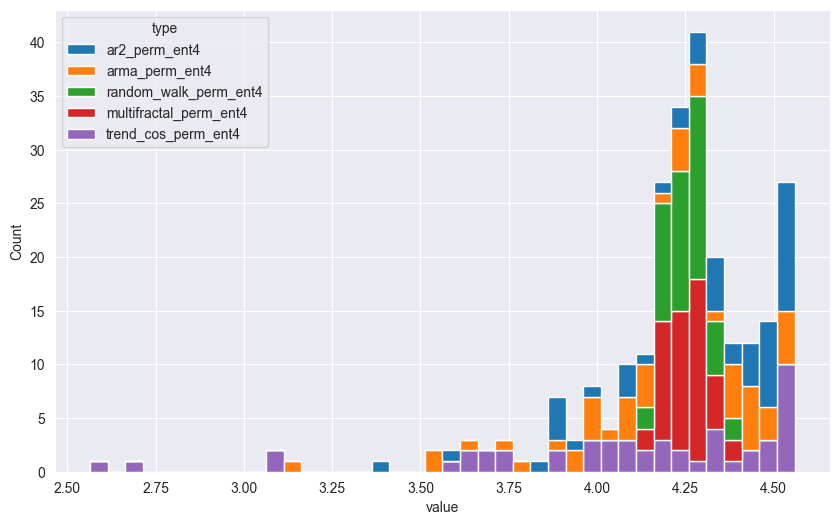

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(data=characteristics_df[["ar2_perm_ent4", "arma_perm_ent4", "random_walk_perm_ent4", "multifractal_perm_ent4", "trend_cos_perm_ent4"]].melt(var_name="type"), x="value", binwidth=0.05, hue="type", alpha=1, multiple="stack")

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(data=characteristics_df[["ar2_stationary4", "arma_stationary4", "random_walk_stationary4", "multifractal_stationary4", "trend_cos_stationary4"]].melt(var_name="type"), x="value", binwidth=0.05, hue="type", alpha=1, multiple="stack")

KeyError: "None of [Index(['ar2_stationary4', 'arma_stationary4', 'random_walk_stationary4',\n       'multifractal_stationary4', 'trend_cos_stationary4'],\n      dtype='object')] are in the [columns]"

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='value', ylabel='Count'>

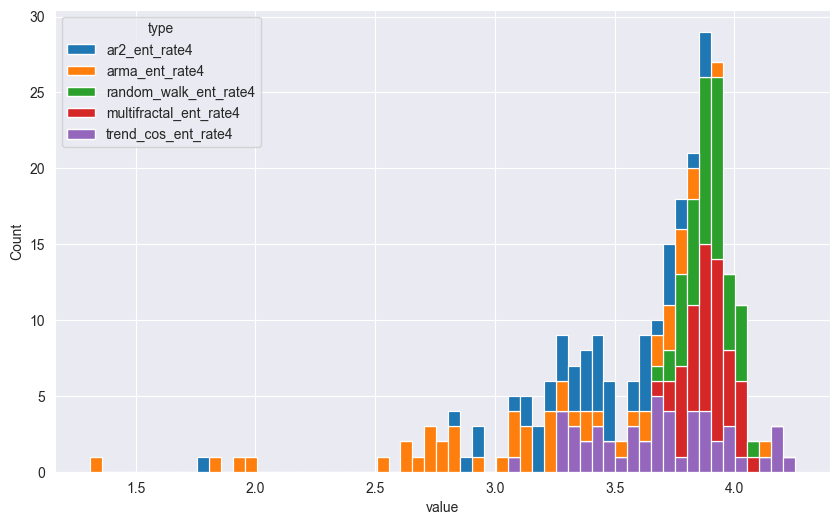

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(data=characteristics_df[["ar2_ent_rate4", "arma_ent_rate4", "random_walk_ent_rate4", "multifractal_ent_rate4", "trend_cos_ent_rate4"]].melt(var_name="type"), x="value", binwidth=0.05, hue="type", alpha=1, multiple="stack")

<Axes: xlabel='value', ylabel='Count'>

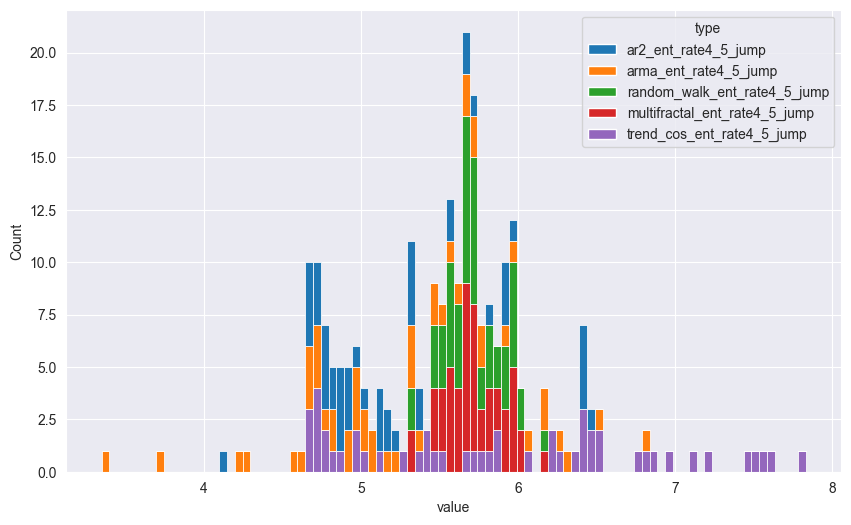

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(data=characteristics_df[["ar2_ent_rate4_5_jump", "arma_ent_rate4_5_jump", "random_walk_ent_rate4_5_jump", "multifractal_ent_rate4_5_jump", "trend_cos_ent_rate4_5_jump"]].melt(var_name="type"), x="value", binwidth=0.05, hue="type", alpha=1, multiple="stack")

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(data=characteristics_df[["ar2_ent_rate4_10_jump", "arma_ent_rate4_10_jump", "random_walk_ent_rate4_10_jump", "multifractal_ent_rate4_10_jump", "trend_cos_ent_rate4_10_jump"]].melt(var_name="type"), x="value", binwidth=0.05, hue="type", alpha=1, multiple="stack")

KeyError: "None of [Index(['ar2_ent_rate4_10_jump', 'arma_ent_rate4_10_jump',\n       'random_walk_ent_rate4_10_jump', 'multifractal_ent_rate4_10_jump',\n       'trend_cos_ent_rate4_10_jump'],\n      dtype='object')] are in the [columns]"

<Figure size 1000x600 with 0 Axes>

In [31]:
def cutting_name(name):
    return name.split('_')[0]

df1=characteristics_df[["ar2_ent_rate4_5_jump", "arma_ent_rate4_5_jump", "random_walk_ent_rate4_5_jump", "multifractal_ent_rate4_5_jump", "trend_cos_ent_rate4_5_jump"]].melt(var_name="type")

df1['type'] = df1['type'].apply(cutting_name)
df2 = characteristics_df[["ar2_ent_rate4", "arma_ent_rate4", "random_walk_ent_rate4", "multifractal_ent_rate4", "trend_cos_ent_rate4"]].melt(var_name="type")
df = df1.copy()
df['value1'] = df2['value']
df.head()

,type,value,value1
0,ar2,5.680069,3.711593
1,ar2,4.894937,3.199126
2,ar2,4.759608,3.430593
3,ar2,4.869158,3.346213
4,ar2,5.369552,3.720815


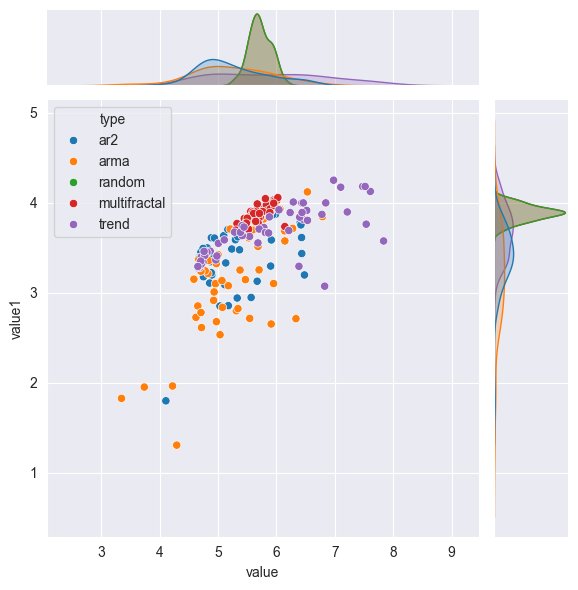

In [32]:
g = sns.jointplot(
    data=df,
    x="value", y="value1", hue="type",
    kind="scatter")

In [33]:
def make_forecast(dataset, forecast_func, forecast_length):
    """
    Make forecasts for each time series in the dataset.

    Parameters:
        dataset (pandas.DataFrame): Input dataset where each row represents a time series.
        forecast_func (function): Function for making forecasts. This function should take a time series
                                  as input and return the forecasted values.
        forecast_length (int): Length of the forecast horizon.

    Returns:
        pandas.DataFrame: DataFrame containing the forecasted values.
    """
    # Create an empty DataFrame to store the forecasted values
    forecasted_dataset = pd.DataFrame(columns=dataset.columns[len(dataset.columns)-forecast_length:])

    # Iterate over each row (time series) in the dataset
    for index, row in dataset.iterrows():
        # Extract the time series
        time_series = row.values
        
        # Make the forecast using the provided function
        forecast = forecast_func(time_series[:len(time_series) - forecast_length], forecast_length)
        
        # Create a new column in the forecasted dataset with the forecasted values
        forecasted_dataset.loc[index] = forecast
    
    return forecasted_dataset

In [46]:
predictions = {"ar2": make_forecast(dataset_df["ar2"], ar2_forecast, 20),
               "arma": make_forecast(dataset_df["arma"], arma_forecast, 20),
               "multifractal": make_forecast(dataset_df["multifractal"], naive_forecast, 20),
               "random_walk": make_forecast(dataset_df["random_walk"], naive_forecast, 20),
               "trend_cos": trend_series_wo_noise.iloc[:, [i for i in range(trend_series_wo_noise.shape[1] - 20, trend_series_wo_noise.shape[1])]]}

C:\Users\vitya\Work\predan\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\vitya\Work\predan\venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\vitya\Work\predan\venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\vitya\Work\predan\venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\vitya\Work\predan\venv\lib\site-packa

In [47]:
from sklearn.metrics import mean_squared_error

def calculate_metrics(real_dataset, predicted_dataset):
    """
    Calculate SMAPE, MASE, and RMSE metrics for each pair of time series in the datasets.

    Parameters:
        real_dataset (pandas.DataFrame): DataFrame containing real values, where each row represents a time series.
        predicted_dataset (pandas.DataFrame): DataFrame containing predicted values, where each row represents a time series.
        
    Returns:
        pandas.DataFrame: DataFrame containing SMAPE, MASE, and RMSE metrics for each pair of time series.
    """
    # Initialize lists to store the metrics
    smape_scores = []
    mase_scores = []
    rmse_scores = []

    # Iterate over each pair of real and predicted time series
    for real_series, predicted_series in zip(real_dataset.values, predicted_dataset.values):
        # Calculate SMAPE
        smape = symmetric_mean_absolute_percentage_error(real_series[len(real_series) - len(predicted_series):], predicted_series)
        smape_scores.append(smape)

        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(real_series[len(real_series) - len(predicted_series):], predicted_series))
        rmse_scores.append(rmse)

        # Calculate MASE
        mase = mean_absolute_scaled_error(real_series[:len(real_series) - len(predicted_series)], real_series[len(real_series) - len(predicted_series):], predicted_series, 1)
        mase_scores.append(mase)

    # Create a DataFrame to store the metrics
    metrics_df = pd.DataFrame({
        'SMAPE': smape_scores,
        'MASE': mase_scores,
        'RMSE': rmse_scores
    })

    return metrics_df

In [48]:
metrics_df = {'ar2': calculate_metrics(dataset_df["ar2"], predictions['ar2']),
              'arma': calculate_metrics(dataset_df["arma"], predictions['arma']),
              'multifractal': calculate_metrics(dataset_df["multifractal"], predictions['multifractal']),
              'random_walk': calculate_metrics(dataset_df["random_walk"], predictions['random_walk']),
              'trend_cos': calculate_metrics(dataset_df["trend_cos"], predictions['trend_cos'])}

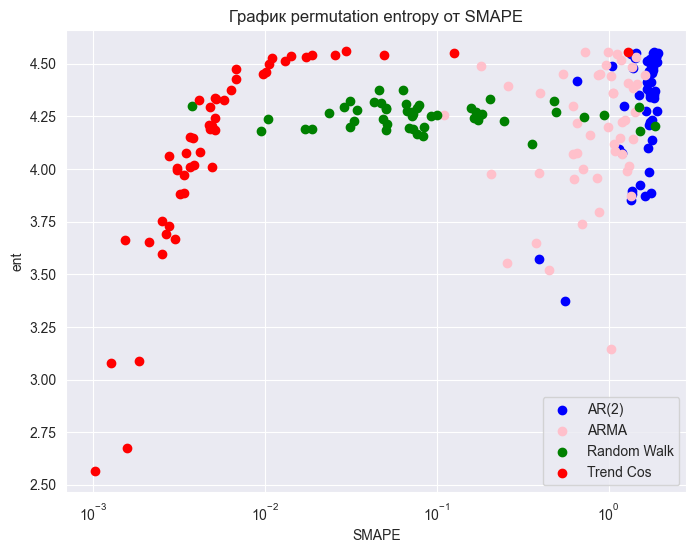

In [49]:
plt.figure(figsize=(8, 6))
plt.scatter(metrics_df['ar2']['SMAPE'], characteristics_df["ar2_perm_ent4"], color='blue', label='AR(2)')
plt.scatter(metrics_df['arma']['SMAPE'], characteristics_df["arma_perm_ent4"], color='pink', label='ARMA')
plt.scatter(metrics_df['random_walk']['SMAPE'], characteristics_df["random_walk_perm_ent4"], color='green', label='Random Walk')
#plt.scatter(metrics_df['multifractal']['SMAPE'], characteristics_df["multifractal_ent_rate4"], color='orange', label='Multifractal')
plt.scatter(metrics_df['trend_cos']['SMAPE'], characteristics_df["trend_cos_perm_ent4"], color='red', label='Trend Cos')
plt.title('График permutation entropy от SMAPE')
plt.xlabel('SMAPE')
plt.ylabel('ent')
plt.semilogx()
plt.grid(True)
plt.legend()
plt.show()

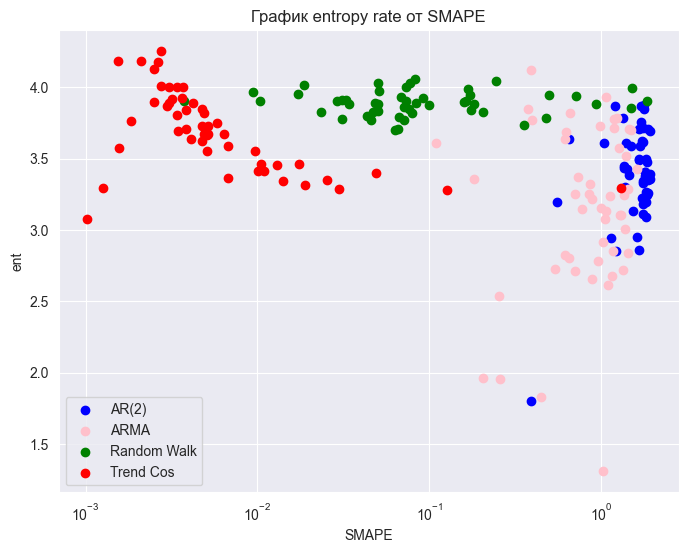

In [50]:
plt.figure(figsize=(8, 6))
plt.scatter(metrics_df['ar2']['SMAPE'], characteristics_df["ar2_ent_rate4"], color='blue', label='AR(2)')
plt.scatter(metrics_df['arma']['SMAPE'], characteristics_df["arma_ent_rate4"], color='pink', label='ARMA')
plt.scatter(metrics_df['random_walk']['SMAPE'], characteristics_df["random_walk_ent_rate4"], color='green', label='Random Walk')
#plt.scatter(metrics_df['multifractal']['SMAPE'], characteristics_df["multifractal_ent_rate4"], color='orange', label='Multifractal')
plt.scatter(metrics_df['trend_cos']['SMAPE'], characteristics_df["trend_cos_ent_rate4"], color='red', label='Trend Cos')
plt.title('График entropy rate от SMAPE')
plt.xlabel('SMAPE')
plt.ylabel('ent')
plt.semilogx()
plt.grid(True)
plt.legend()
plt.show()

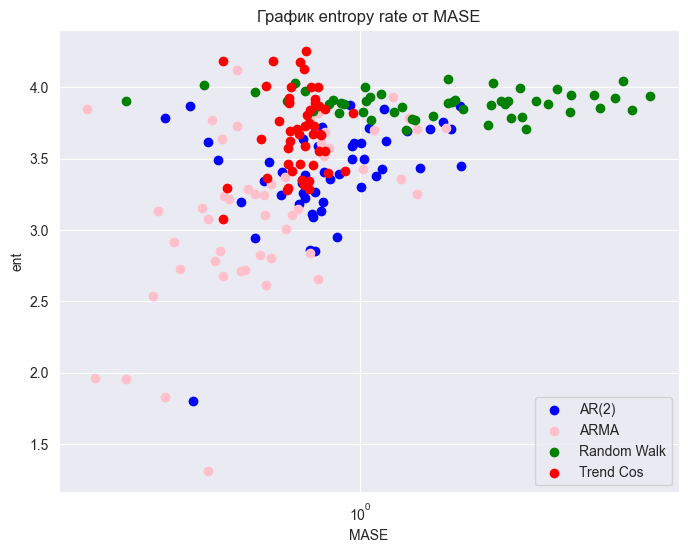

In [51]:
plt.figure(figsize=(8, 6))
plt.scatter(metrics_df['ar2']['MASE'], characteristics_df["ar2_ent_rate4"], color='blue', label='AR(2)')
plt.scatter(metrics_df['arma']['MASE'], characteristics_df["arma_ent_rate4"], color='pink', label='ARMA')
plt.scatter(metrics_df['random_walk']['MASE'], characteristics_df["random_walk_ent_rate4"], color='green', label='Random Walk')
#plt.scatter(metrics_df['multifractal']['SMAPE'], characteristics_df["multifractal_ent_rate4"], color='orange', label='Multifractal')
plt.scatter(metrics_df['trend_cos']['MASE'], characteristics_df["trend_cos_ent_rate4"], color='red', label='Trend Cos')
plt.title('График entropy rate от MASE')
plt.xlabel('MASE')
plt.ylabel('ent')
plt.semilogx()
plt.grid(True)
plt.legend()
plt.show()

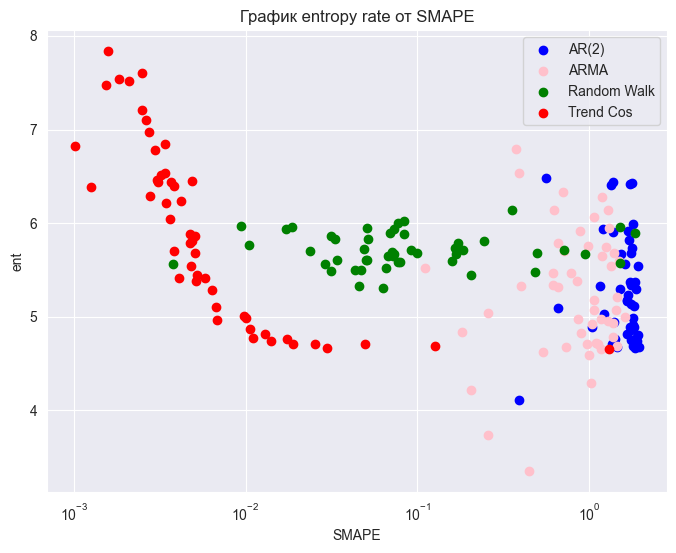

In [52]:
plt.figure(figsize=(8, 6))
plt.scatter(metrics_df['ar2']['SMAPE'], characteristics_df["ar2_ent_rate4_5_jump"], color='blue', label='AR(2)')
plt.scatter(metrics_df['arma']['SMAPE'], characteristics_df["arma_ent_rate4_5_jump"], color='pink', label='ARMA')
plt.scatter(metrics_df['random_walk']['SMAPE'], characteristics_df["random_walk_ent_rate4_5_jump"], color='green', label='Random Walk')
#plt.scatter(metrics_df['multifractal']['SMAPE'], characteristics_df["multifractal_ent_rate4"], color='orange', label='Multifractal')
plt.scatter(metrics_df['trend_cos']['SMAPE'], characteristics_df["trend_cos_ent_rate4_5_jump"], color='red', label='Trend Cos')
plt.title('График entropy rate от SMAPE')
plt.xlabel('SMAPE')
plt.ylabel('ent')
plt.semilogx()
plt.grid(True)
plt.legend()
plt.show()

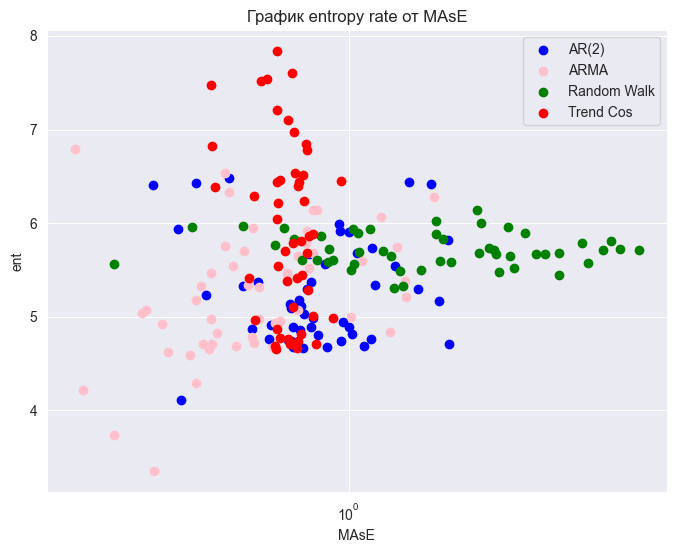

In [53]:
plt.figure(figsize=(8, 6))
plt.scatter(metrics_df['ar2']['MASE'], characteristics_df["ar2_ent_rate4_5_jump"], color='blue', label='AR(2)')
plt.scatter(metrics_df['arma']['MASE'], characteristics_df["arma_ent_rate4_5_jump"], color='pink', label='ARMA')
plt.scatter(metrics_df['random_walk']['MASE'], characteristics_df["random_walk_ent_rate4_5_jump"], color='green', label='Random Walk')
#plt.scatter(metrics_df['multifractal']['SMAPE'], characteristics_df["multifractal_ent_rate4"], color='orange', label='Multifractal')
plt.scatter(metrics_df['trend_cos']['MASE'], characteristics_df["trend_cos_ent_rate4_5_jump"], color='red', label='Trend Cos')
plt.title('График entropy rate от MAsE')
plt.xlabel('MAsE')
plt.ylabel('ent')
plt.semilogx()
plt.grid(True)
plt.legend()
plt.show()

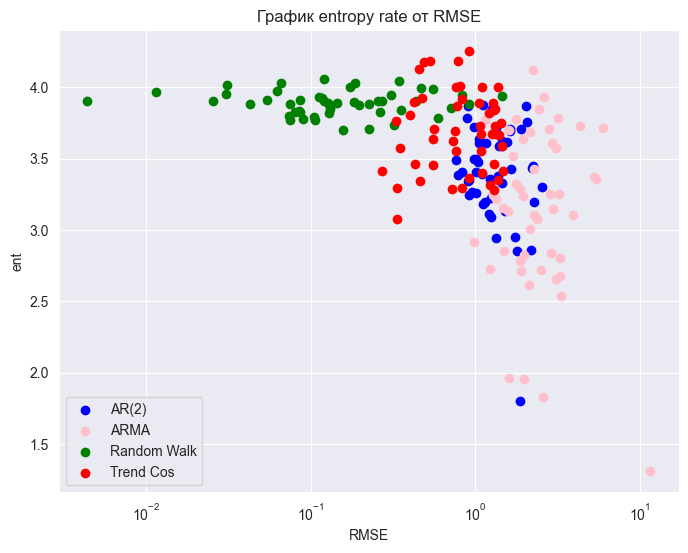

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(metrics_df['ar2']['RMSE'], characteristics_df["ar2_ent_rate4"], color='blue', label='AR(2)')
plt.scatter(metrics_df['arma']['RMSE'], characteristics_df["arma_ent_rate4"], color='pink', label='ARMA')
plt.scatter(metrics_df['random_walk']['RMSE'], characteristics_df["random_walk_ent_rate4"], color='green', label='Random Walk')
#plt.scatter(metrics_df['multifractal']['SMAPE'], characteristics_df["multifractal_ent_rate4"], color='orange', label='Multifractal')
plt.scatter(metrics_df['trend_cos']['RMSE'], characteristics_df["trend_cos_ent_rate4"], color='red', label='Trend Cos')
plt.title('График entropy rate от RMSE')
plt.xlabel('RMSE')
plt.ylabel('ent')
plt.semilogx()
plt.grid(True)
plt.legend()
plt.show()

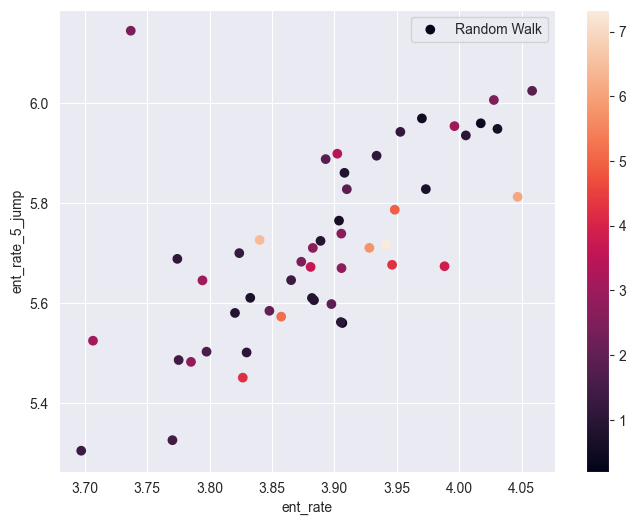

In [58]:
plt.figure(figsize=(8, 6))
#plt.scatter(characteristics_df["ar2_ent_rate4"], characteristics_df["ar2_ent_rate4_5_jump"], c=metrics_df['ar2']['MASE'], label='AR(2)')
#plt.scatter(characteristics_df["arma_ent_rate4"], characteristics_df["arma_ent_rate4_5_jump"], c=metrics_df['arma']['MASE'], label='ARMA')
plt.scatter(characteristics_df["random_walk_ent_rate4"], characteristics_df["random_walk_ent_rate4_5_jump"], c=metrics_df['random_walk']['MASE'], label='Random Walk')
#plt.scatter(characteristics_df["trend_cos_ent_rate4"], characteristics_df["trend_cos_ent_rate4_5_jump"], c=metrics_df['trend_cos']['MASE'], label='Trend Cos')
plt.colorbar()
plt.xlabel('ent_rate')
plt.ylabel('ent_rate_5_jump')
plt.grid(True)
plt.legend()
plt.show()

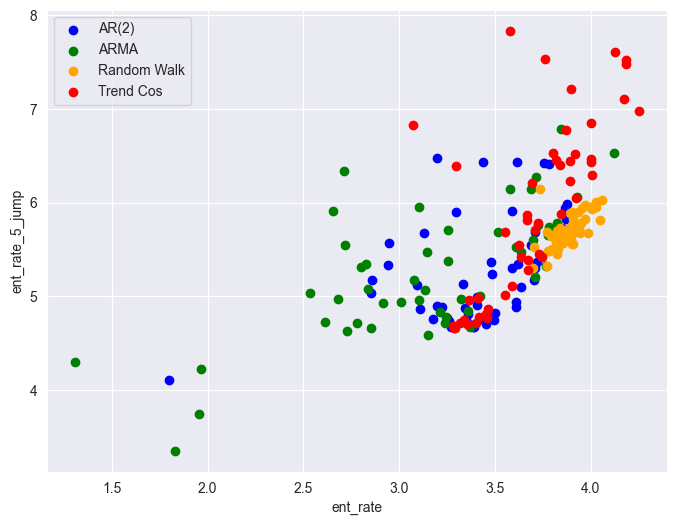

In [56]:
plt.figure(figsize=(8, 6))
plt.scatter(characteristics_df["ar2_ent_rate4"], characteristics_df["ar2_ent_rate4_5_jump"], color = 'b', label='AR(2)')
plt.scatter(characteristics_df["arma_ent_rate4"], characteristics_df["arma_ent_rate4_5_jump"], color='g', label='ARMA')
plt.scatter(characteristics_df["random_walk_ent_rate4"], characteristics_df["random_walk_ent_rate4_5_jump"], color="orange", label='Random Walk')
plt.scatter(characteristics_df["trend_cos_ent_rate4"], characteristics_df["trend_cos_ent_rate4_5_jump"], color="red", label='Trend Cos')
plt.xlabel('ent_rate')
plt.ylabel('ent_rate_5_jump')
plt.grid(True)
plt.legend()
plt.show()